![line.jpg](img/line.jpg)


목표치 : (3시 기준) 67도, 112도, 247도, 292도 

In [1]:
import cv2 as cv 
import numpy as np
import matplotlib.pyplot as plt
import sys

In [2]:
img = cv.imread('img/wayline.tif')
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

In [ ]:
kernel_45 = np.array([
    [-2, -1,  0],
    [-1,  0,  1],
    [ 0,  1,  2]
], dtype=np.float32)

kernel_N45 = np.array([
    [ 0,  1,  2],
    [-1,  0,  1],
    [-2, -1,  0]
], dtype=np.float32)


# 67도 마스크
mask_67 = np.array([
    [ 2,  3,  4,  4,  5],
    [ 0,  1,  2,  3,  4],
    [-2, -1,  0,  1,  2],
    [-4, -3, -2, -1,  0],
    [-5, -4, -4, -3, -2]
])


mask_67_2 = np.array([
    [-3, -2, -1,  0,  1],
    [-2, -1,  0,  1,  2],
    [-1,  0,  0,  0,  1],
    [ 0,  1,  0, -1, -2],
    [ 1,  2,  1, -2, -3]
], dtype=np.float32)

refined_mask_67 = np.array([
    [ 0,  0,  1,  2,  5],
    [ 0,  0,  1,  3,  2],
    [-2, -1,  0,  1,  2],
    [-2, -3, -1,  0,  0],
    [-5, -2, -1,  0,  0]
])


# 112도 마스크
mask_112 = np.array([
    [ 5,  4,  4,  3,  2],
    [ 4,  3,  2,  1,  0],
    [ 2,  1,  0, -1, -2],
    [ 0, -1, -2, -3, -4],
    [-2, -3, -4, -4, -5]
])

# 247도 마스크
mask_247 = np.array([
    [-2, -3, -4, -4, -5],
    [ 0, -1, -2, -3, -4],
    [ 2,  1,  0, -1, -2],
    [ 4,  3,  2,  1,  0],
    [ 5,  4,  4,  3,  2]
])

# 292도 마스크
mask_292 = np.array([
    [-5, -4, -4, -3, -2],
    [-4, -3, -2, -1,  0],
    [-2, -1,  0,  1,  2],
    [ 0,  1,  2,  3,  4],
    [ 2,  3,  4,  4,  5]
])



1차적 시도,   
4번 과제의 소빌 마스크를 변형한 것과 같이   
필요한 마스크를 직접 설계해서 해보는 시도  

In [ ]:

grad_1 = cv.Sobel(gray,cv.CV_32F,1,0,ksize=3)
grad_2 = cv.Sobel(grad_1,cv.CV_32F,0,1,ksize=3)
grad_3 = cv.filter2D(grad_2, cv.CV_32F, kernel_45)
grad_4 = cv.filter2D(grad_3, cv.CV_32F, kernel_N45)
grad_67 = cv.filter2D(grad_4, cv.CV_32F, mask_67_2)

grad_112 = cv.filter2D(gray, cv.CV_32F, mask_112 )
grad_247 = cv.filter2D(gray, cv.CV_32F, mask_247)
grad_292 = cv.filter2D(gray, cv.CV_32F, mask_292)

abs_67  = cv.convertScaleAbs(grad_67)
abs_112 = cv.convertScaleAbs(grad_112)
abs_247 = cv.convertScaleAbs(grad_247)
abs_292 = cv.convertScaleAbs(grad_292)

combined_target = cv.addWeighted(abs_67, 0.5, abs_112, 0.5, 0)

top = cv.hconcat([gray, abs_67, abs_112])
bottom = cv.hconcat([combined_target, abs_247, abs_292])

combined_small = cv.resize(cv.vconcat([top, bottom]), None, fx=0.3, fy=0.3)


cv.imshow('ed', combined_small)

cv.waitKey()
cv.destroyAllWindows()

# 버려진 코드


NameError: name 'mask_292' is not defined

여러번 시도했지만 중첩하면 특정 부위를 삭제는 가능    
그러나 찾아본 글과 자료에서는 이렇게 하면 노이즈가 증폭되고   
나중에 합성하는 수가 많다보니 그 때도 노이즈로 인한 외곡이 심해진다고 함  


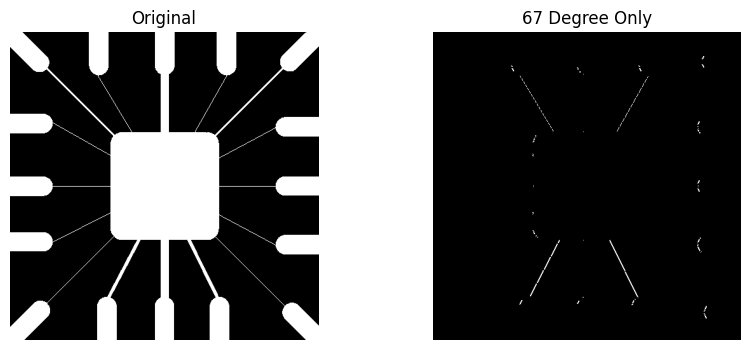

In [ ]:

gx = cv.Sobel(gray, cv.CV_32F, 1, 0, ksize=3)
gy = cv.Sobel(gray, cv.CV_32F, 0, 1, ksize=3)

magnitude = np.sqrt(gx**2 + gy**2)
angle = np.arctan2(gy, gx) * 180 / np.pi

angle = np.abs(angle)
target_angle = 22 # (<-12시 기준) 3시 기준 67 도
tolerance = 8   

mask = (angle > target_angle - tolerance) & \
       (angle < target_angle + tolerance) & \
       (magnitude > 40)


result = np.zeros_like(gray)
result[mask] = 255

# 출력
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result, cmap='gray')
plt.title('67 도 (3시 기준)')
plt.axis('off')

plt.show()


edge를 검출할 수 있도록 mask를 변수를 사용해서 특정할 수 있다는 것을 알게되었다. 

중앙을 중심으로 12시 기준 360도에서 필요한 방향으로 계산 하였더니 위와 같이 필요한 선을 추출하는데 성공했다. 


(np.float64(-0.5), np.float64(485.5), np.float64(485.5), np.float64(-0.5))

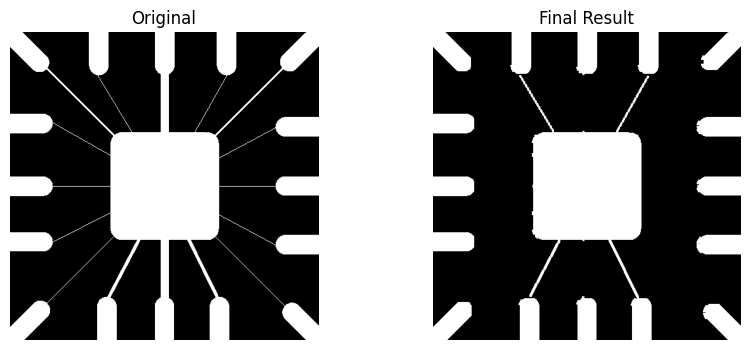

In [24]:
# kernel = np.ones((5, 5), np.uint8)
# kernel = np.ones((7, 7), np.uint8)
# kernel = np.ones((9, 9), np.uint8) 
# kernel = np.ones((11,11), np.uint8) 
# kernel = np.ones((13,13), np.uint8) 
kernel = np.ones((15, 15), np.uint8)
base_struct = cv.morphologyEx(gray, cv.MORPH_OPEN, kernel)

line_dilated = cv.dilate(result, np.ones((3, 3), np.uint8), iterations=1)
final_result = cv.bitwise_or(base_struct, line_dilated)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(final_result, cmap='gray')
plt.title('Final Result')
plt.axis('off')



마지막으로 모폴로지를 사용해 원본 선은 미리 모두 침식시킨 이후에   
이전의 edge가 검출된 영상과 합쳐서 최종 결과를 도출한다.   
합치는 과정에서 edge가 팽창한 것으로 보이기에   
추가적인 팽창은 하지 않았다  
